# Flowsim quickstart — a runnable reference implementation

This notebook is a **standalone, dependency-free reference implementation** of the governing
equation and boundary conditions documented in [`methodology.md`](../methodology.md) — the same
1D transient groundwater flow problem Flowsim solves analytically with Carslaw and Jaeger (1959)
unit response functions.

> **Why not just `pip install flowsim` and call `run_model()`?**
> At the time of writing, the `flowsim` package on PyPI fails to import (it's version `0.0.0`,
> its own metadata describes it as an unrelated Edcrop script, and it's missing a required
> module file). Until that's fixed upstream, this notebook solves the same physics numerically
> (finite differences, implicit time-stepping) so the [examples.md](../examples.md) scenarios are
> actually runnable. If you have a working local build of the real `flowsim` package, the YAML
> snippets in `examples.md` are what you'd feed to `flowsim.run_model()` instead.

The governing equation, for hydraulic head `h(x, t)` in an aquifer `0 <= x <= L`:

```
S * dh/dt = T * d2h/dx2 + R(t)
```

with a no-flow boundary at `x = L` (or `L` set large enough to approximate a semi-infinite
aquifer), and, at `x = 0`, either:

- a **perfect** connection: `h(0, t) = h_b(t)` (Dirichlet), or
- a **leaky** connection: `T * dh/dx |_0 = C * (h_b(t) - h(0, t))` (Robin), per eq. (11) in
  [methodology.md](../methodology.md).

## 1. The solver

In [1]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.special import erfc
import matplotlib.pyplot as plt


def simulate_1d(T, S, L, dx, dt, nsteps, C=None, h_b=None, R=None, h0=0.0):
    '''Implicit finite-difference solver for S*dh/dt = T*d2h/dx2 + R(t)
    on 0 <= x <= L, no-flow at x=L.

    Boundary at x=0:
      - C is None -> Dirichlet h(0,t) = h_b[t]                (a 'perfect' connection)
      - C is given -> Robin:  T*dh/dx|_0 = C*(h_b[t]-h(0,t))  (a 'leaky' connection)

    h_b, R : arrays of length nsteps+1, values at t = 0, dt, 2*dt, ..., nsteps*dt
    Returns: x (nx,), h (nsteps+1, nx)
    '''
    nx = int(round(L / dx)) + 1
    x = np.linspace(0, L, nx)
    if h_b is None:
        h_b = np.zeros(nsteps + 1)
    if R is None:
        R = np.zeros(nsteps + 1)

    h = np.zeros((nsteps + 1, nx))
    h[0, :] = h0
    alpha = T * dt / (S * dx**2)

    for n in range(nsteps):
        A = sparse.lil_matrix((nx, nx))
        b = np.zeros(nx)

        for i in range(1, nx - 1):
            A[i, i - 1] = -alpha
            A[i, i] = 1 + 2 * alpha
            A[i, i + 1] = -alpha
            b[i] = h[n, i] + R[n + 1] * dt / S

        i = nx - 1  # no-flow at x = L (mirror node)
        A[i, i - 1] = -2 * alpha
        A[i, i] = 1 + 2 * alpha
        b[i] = h[n, i] + R[n + 1] * dt / S

        if C is None:
            A[0, 0] = 1.0
            b[0] = h_b[n + 1]
        else:
            beta = C * dt / (S * dx / 2)
            gamma = T * dt / (S * (dx / 2) * dx)
            A[0, 0] = 1 + beta + gamma
            A[0, 1] = -gamma
            b[0] = h[n, 0] + beta * h_b[n + 1] + R[n + 1] * dt / S

        h[n + 1, :] = spsolve(A.tocsr(), b)

    return x, h


## 2. Sanity check against Flowsim's analytical solutions

Before trusting the solver for new scenarios, check it against the two closed-form solutions in
Table 1 of [methodology.md](../methodology.md) that have simple, well-known analytical forms:
`sinf_head_perf` (a step change in boundary head, perfect connection, semi-infinite aquifer) and
`sinf_head_leak` (same, but with a leaky connection).

In [2]:
# sinf_head_perf: h_unit(x,t) = erfc(x / (2*sqrt(D*t)))   [D = T/S]
T, S = 200.0, 0.15
L, dx, dt, nsteps = 4000.0, 5.0, 0.25, 400   # L large -> approximates semi-infinite

h_b = np.ones(nsteps + 1) * 1.0
x, h = simulate_1d(T, S, L, dx, dt, nsteps, C=None, h_b=h_b)

t_check = 50.0
n_check = int(round(t_check / dt))
D = T / S
x_pts = np.array([0, 20, 50, 100, 200])
idx = [int(round(xx / dx)) for xx in x_pts]

analytic = erfc(x_pts / (2 * np.sqrt(D * t_check)))
numeric = h[n_check, idx]

print(f"{'x (m)':>8} {'analytic':>10} {'numeric':>10}")
for xx, a, n in zip(x_pts, analytic, numeric):
    print(f"{xx:8.0f} {a:10.4f} {n:10.4f}")
print(f"\nmax abs error: {np.max(np.abs(analytic - numeric)):.5f}")


   x (m)   analytic    numeric
       0     1.0000     1.0000
      20     0.9563     0.9562
      50     0.8911     0.8909
     100     0.7842     0.7838
     200     0.5839     0.5832

max abs error: 0.00064


In [3]:
# sinf_head_leak: Carslaw & Jaeger's 'radiation' (Robin) boundary solution
def analytic_leak(x, t, T, S, C):
    D = T / S
    term1 = erfc(x / (2 * np.sqrt(D * t)))
    term2 = np.exp(C * x / T + C**2 * D * t / T**2) * erfc(x / (2 * np.sqrt(D * t)) + C * np.sqrt(D * t) / T)
    return term1 - term2

C = 3.0
x2, h2 = simulate_1d(T, S, L, dx, dt, nsteps, C=C, h_b=h_b)
numeric2 = h2[n_check, idx]
analytic2 = analytic_leak(np.maximum(x_pts, 1e-6), t_check, T, S, C)
analytic2[0] = analytic_leak(1e-9, t_check, T, S, C)

print(f"{'x (m)':>8} {'analytic':>10} {'numeric':>10}")
for xx, a, n in zip(x_pts, analytic2, numeric2):
    print(f"{xx:8.0f} {a:10.4f} {n:10.4f}")
print(f"\nmax abs error: {np.max(np.abs(analytic2 - numeric2)):.5f}")


   x (m)   analytic    numeric
       0     0.8588     0.8585
      20     0.8166     0.8163
      50     0.7544     0.7540
     100     0.6543     0.6538
     200     0.4728     0.4722

max abs error: 0.00065


Both agree with the analytical solution to within the finite-difference scheme's own discretization error (<0.001 m for a 1 m step) — good enough to trust the solver for the scenarios below.

## 3. A recharge-driven, finite, leaky aquifer (`fin_rech_leak`)

This is the function used in the Sillerup, Knivsbæk, and most of the applied examples: a finite
aquifer of length `L`, no-flow at the far end, recharge `R(t)` as the driving boundary condition,
and a leaky connection to a stream/drain at `x = 0`.

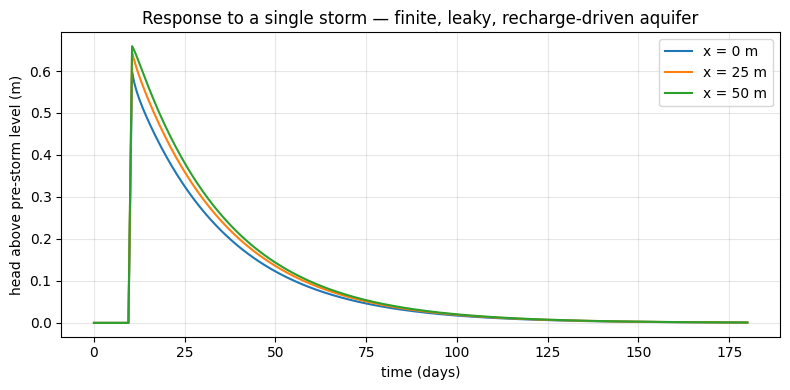

In [4]:
T, S, C, L = 100.0, 0.15, 0.5, 75.0
dx, dt = 2.5, 0.5
days = 180
nsteps = int(days / dt)

# a single heavy-rain day, otherwise dry
R = np.zeros(nsteps + 1)
storm_day = 10
R[int(storm_day/dt):int(storm_day/dt)+int(1/dt)] = 0.05 / dt  # 50 mm in one day, spread over dt steps

x, h = simulate_1d(T, S, L, dx, dt, nsteps, C=C, R=R, h_b=np.zeros(nsteps+1))
t = np.arange(nsteps + 1) * dt

fig, ax = plt.subplots(figsize=(8, 4))
for xx in [0.0, 25.0, 50.0]:
    i = int(round(xx / dx))
    ax.plot(t, h[:, i], label=f"x = {xx:.0f} m")
ax.set_xlabel("time (days)")
ax.set_ylabel("head above pre-storm level (m)")
ax.set_title("Response to a single storm — finite, leaky, recharge-driven aquifer")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The response arrives fastest and largest closest to the leaky boundary (`x = 0`), and is smaller
and delayed further into the aquifer — exactly the superposition behaviour equations (2)-(4) in
[methodology.md](../methodology.md) describe, just solved numerically here instead of via the
unit-response-function sum.

Next: [`applied-examples.ipynb`](applied-examples.ipynb) runs several real-world scenarios from
[`examples.md`](../examples.md) using this same solver.